1. Importing & Installing the Dependencies

In [1]:
# ── INSTALL DEPENDENCIES ──────────────────────────────────────────────────────
# Run these in a separate cell if on Jupyter/Kaggle/Colab

!pip install xgboost shap imbalanced-learn

In [2]:
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

from pandas.core.frame import DataFrame as df

from imblearn.over_sampling import SMOTE #Over-sampling technique used for building uniformly distributed target class

from xgboost import XGBClassifier

import shap

import pickle


2. Data Loading and Understanding

In [3]:
# load data
df = pd.read_csv("/kaggle/input/datasets/sibelius5/telco-customer-churn/Telco_customer_churn_cleaned.csv")
pd.set_option("display.max_columns", None)
df.head(2)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_rate,CLTV,Churn Reason,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Age,Under 30,Married,Referred a Friend,Number of Referrals,Offer,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Streaming Music,Premium Tech Support,Unlimited Data,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Category
0,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,3239,Competitor made better offer,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,37,No,No,No,0,NaN,10.47,21,No,No,Yes,0.0,0,20.94,129.09,1,Churned,Competitor
1,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,2701,Moved,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,19,Yes,No,No,0,NaN,9.12,51,No,No,Yes,0.0,0,18.24,169.89,2,Churned,Other


In [4]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     3668-QPYBK    Male              0      No         No       2   
1     9237-HQITU  Female              0      No         No       2   
2     9305-CDSKC  Female              0      No         No       8   
3     7892-POOKP  Female              0     Yes         No      28   
4     0280-XJGEX    Male              0      No         No      49   
...          ...     ...            ...     ...        ...     ...   
7038  2569-WGERO  Female              0      No         No      72   
7039  6840-RESVB    Male              0     Yes        Yes      24   
7040  2234-XADUH  Female              0     Yes        Yes      72   
7041  4801-JZAZL  Female              0     Yes        Yes      11   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService       OnlineSecurity  \
0             Yes                No             DSL

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'churn_rate', 'CLTV', 'Churn Reason', 'Count', 'Country', 'State',
       'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Age',
       'Under 30', 'Married', 'Referred a Friend', 'Number of Referrals',
       'Offer', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
       'Streaming Music', 'Premium Tech Support', 'Unlimited Data',
       'Total Refunds', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score',
       'Customer Status', 'Churn Category'],
      dtype='object')

In [6]:
print(df["gender"].unique())

['Male' 'Female']


In [7]:
print(df["SeniorCitizen"].unique())

[0 1]


In [8]:
# printing the unique values in all the columns

numerical_features_list = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in df.columns:
  if col not in numerical_features_list:
    print(col, df[col].unique())
    print("-"*50)

customerID ['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']
--------------------------------------------------
gender ['Male' 'Female']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['No' 'Yes']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['Yes' 'No']
--------------------------------------------------
MultipleLines ['No' 'Yes' 'No phone service']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['Yes' 'No' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
---------------------------------------

In [9]:
print(df.isnull().sum())

customerID                              0
gender                                  0
SeniorCitizen                           0
Partner                                 0
Dependents                              0
tenure                                  0
PhoneService                            0
MultipleLines                           0
InternetService                         0
OnlineSecurity                          0
OnlineBackup                            0
DeviceProtection                        0
TechSupport                             0
StreamingTV                             0
StreamingMovies                         0
Contract                                0
PaperlessBilling                        0
PaymentMethod                           0
MonthlyCharges                          0
TotalCharges                            0
Churn                                   0
churn_rate                              0
CLTV                                    0
Churn Reason                      

In [10]:
# dropping customerID column as this is not required for modelling
df = df.drop(columns=["customerID"])
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'churn_rate', 'CLTV',
       'Churn Reason', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Age', 'Under 30', 'Married',
       'Referred a Friend', 'Number of Referrals', 'Offer',
       'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
       'Streaming Music', 'Premium Tech Support', 'Unlimited Data',
       'Total Refunds', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score',
       'Customer Status', 'Churn Category'],
      dtype='object')

In [11]:
# checking the class distribution of target column
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


3. Exploratory Data Analysis

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,churn_rate,CLTV,Count,Zip Code,Latitude,Longitude,Age,Number of Referrals,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370,4400.295755,1.0,93521.964646,36.282441,-119.798880,46.509726,1.951867,22.958954,20.515405,1.962182,6.860713,749.099262,3034.379056,3.244924
std,0.368612,24.559481,30.090047,2266.794470,0.441561,1183.057152,0.0,1865.794555,2.455723,2.157889,16.750352,3.001199,15.448113,20.418940,7.902614,25.104978,846.660055,2865.204542,1.201657
min,0.000000,0.000000,18.250000,0.000000,0.000000,2003.000000,1.0,90001.000000,32.555828,-124.301372,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.360000,1.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000,3469.000000,1.0,92102.000000,34.030915,-121.815412,32.000000,0.000000,9.210000,3.000000,0.000000,0.000000,70.545000,605.610000,3.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000,4527.000000,1.0,93552.000000,36.391777,-119.730885,46.000000,0.000000,22.890000,17.000000,0.000000,0.000000,401.440000,2108.640000,3.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000,5380.500000,1.0,95351.000000,38.224869,-118.043237,60.000000,3.000000,36.395000,27.000000,0.000000,0.000000,1191.100000,4801.145000,4.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000,6500.000000,1.0,96161.000000,41.962127,-114.192901,80.000000,11.000000,49.990000,85.000000,49.790000,150.000000,3564.720000,11979.340000,5.000000


Numerical Features - Analysis

Understand the distribution of teh numerical features

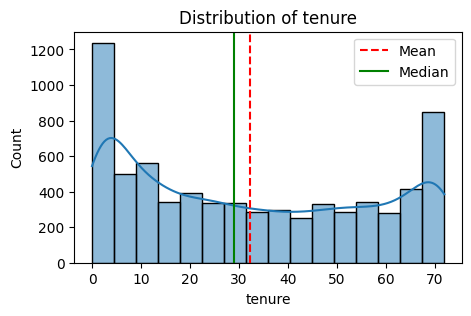

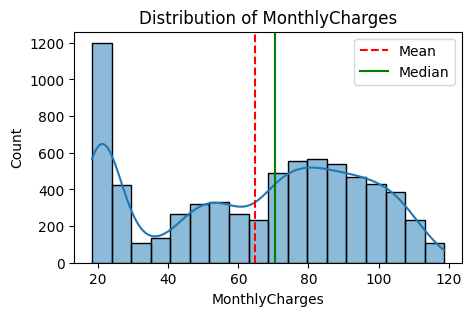

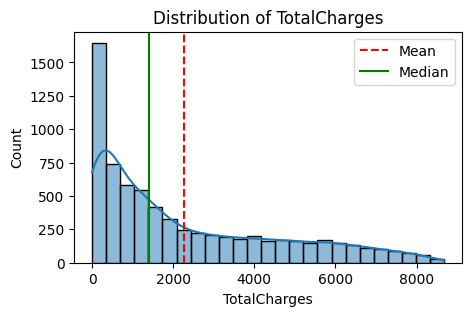

In [13]:
def plot_histogram(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.histplot(df[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")
  # calculate the mean and median values for the columns
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()
  # add vertical lines for mean and median
  plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(col_median, color="green", linestyle="-", label="Median")
  plt.legend()
  plt.show()

plot_histogram(df, "tenure")
plot_histogram(df, "MonthlyCharges")
plot_histogram(df, "TotalCharges")

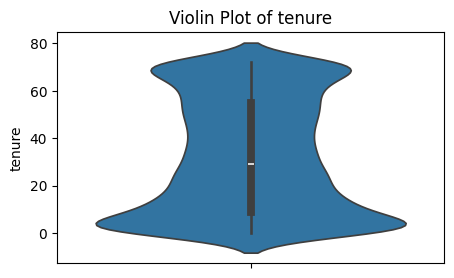

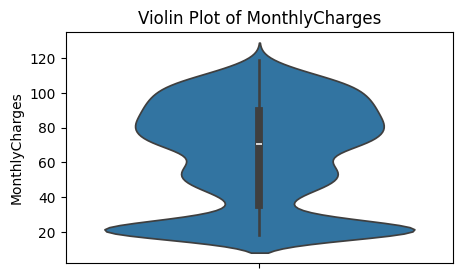

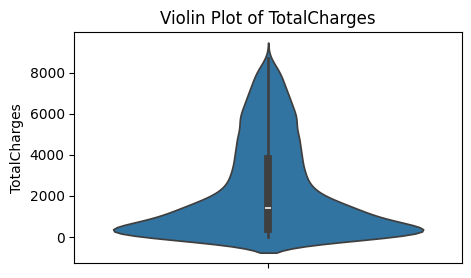

In [14]:
def plot_violinplot(df, column_name):
  plt.figure(figsize=(5, 3))
  sns.violinplot(y=df[column_name])
  plt.title(f"Violin Plot of {column_name}")
  plt.ylabel(column_name)
  plt.show()

plot_violinplot(df, "tenure")
plot_violinplot(df, "MonthlyCharges")
plot_violinplot(df, "TotalCharges")

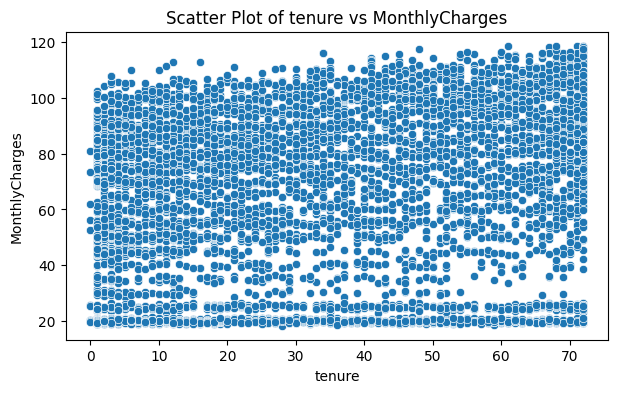

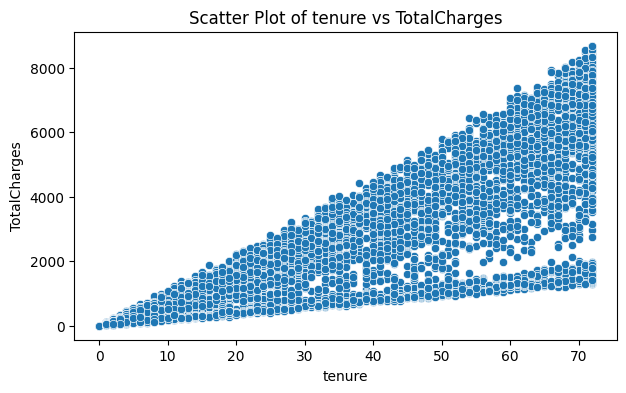

In [15]:
def plot_scatterplot(df, x_column, y_column):
  plt.figure(figsize=(7, 4))
  sns.scatterplot(x=df[x_column], y=df[y_column])
  plt.title(f"Scatter Plot of {x_column} vs {y_column}")
  plt.xlabel(x_column)
  plt.ylabel(y_column)
  plt.show()

# Example: Relationship between tenure and MonthlyCharges
plot_scatterplot(df, "tenure", "MonthlyCharges")

# Example: Relationship between tenure and TotalCharges
plot_scatterplot(df, "tenure", "TotalCharges")

Correlation Heatmap for numerical columns

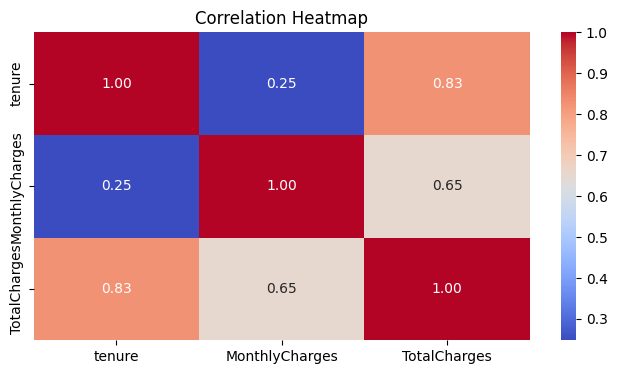

In [16]:
# correlation matrix - heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Categorical features - Analysis

In [17]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'churn_rate', 'CLTV',
       'Churn Reason', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Age', 'Under 30', 'Married',
       'Referred a Friend', 'Number of Referrals', 'Offer',
       'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
       'Streaming Music', 'Premium Tech Support', 'Unlimited Data',
       'Total Refunds', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score',
       'Customer Status', 'Churn Category'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 49 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             7043 non-null   object 
 1   SeniorCitizen                      7043 non-null   int64  
 2   Partner                            7043 non-null   object 
 3   Dependents                         7043 non-null   object 
 4   tenure                             7043 non-null   int64  
 5   PhoneService                       7043 non-null   object 
 6   MultipleLines                      7043 non-null   object 
 7   InternetService                    7043 non-null   object 
 8   OnlineSecurity                     7043 non-null   object 
 9   OnlineBackup                       7043 non-null   object 
 10  DeviceProtection                   7043 non-null   object 
 11  TechSupport                        7043 non-null   objec

Countplot for categorical columns

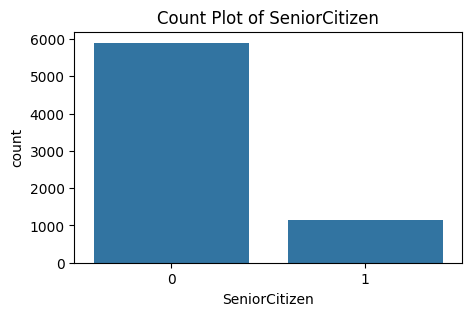

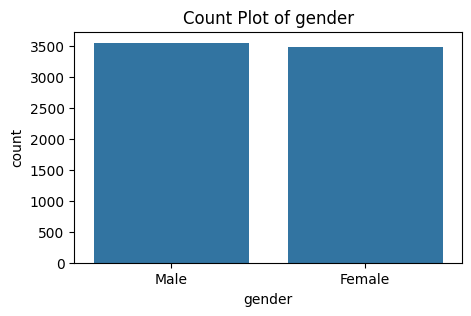

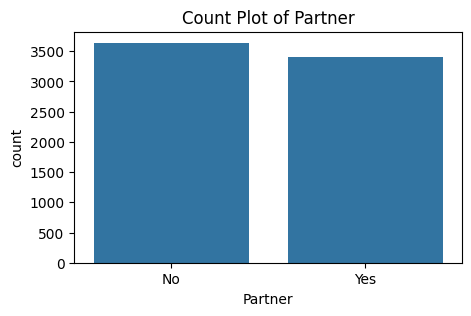

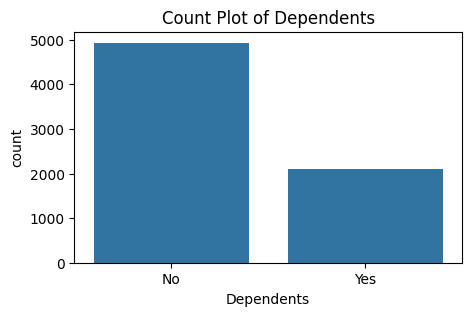

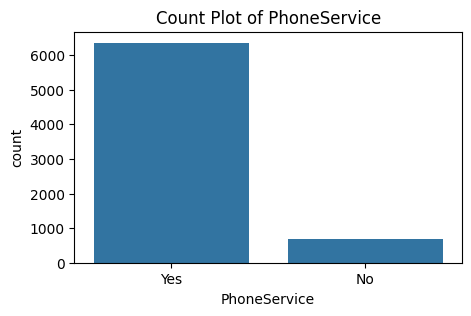

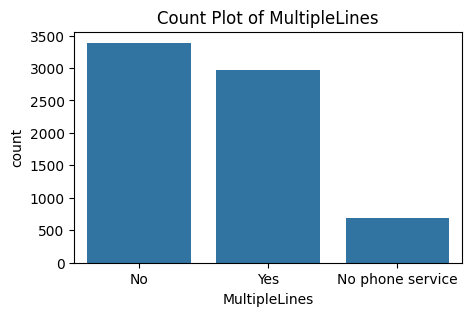

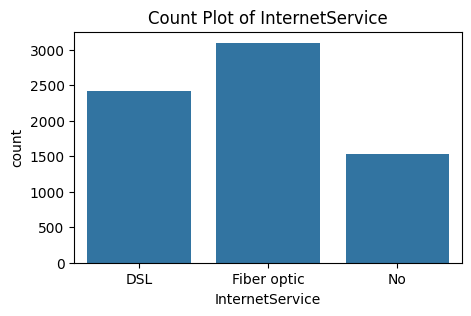

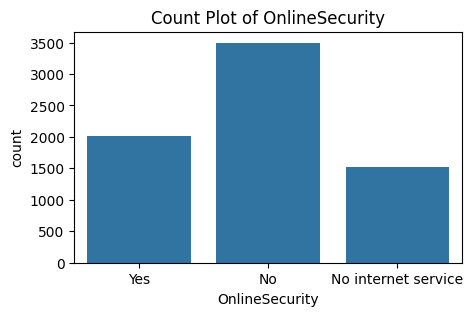

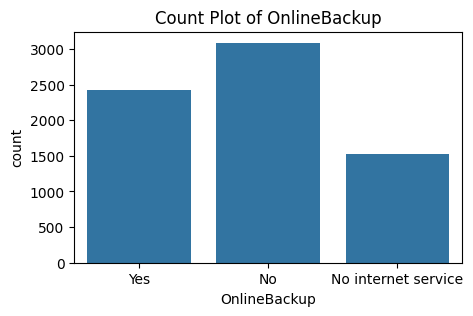

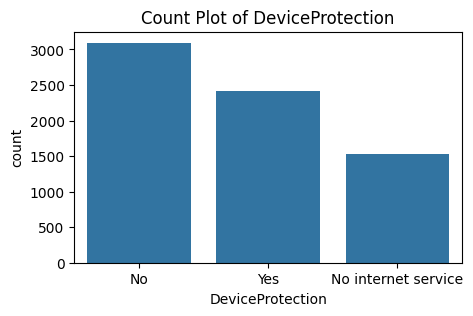

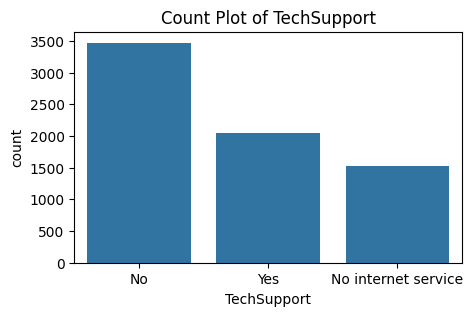

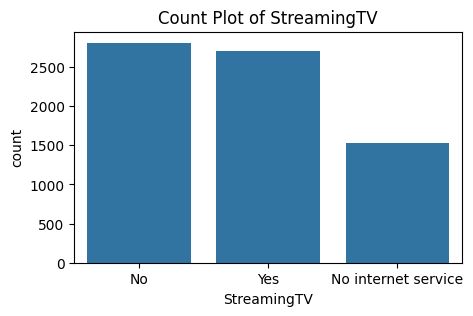

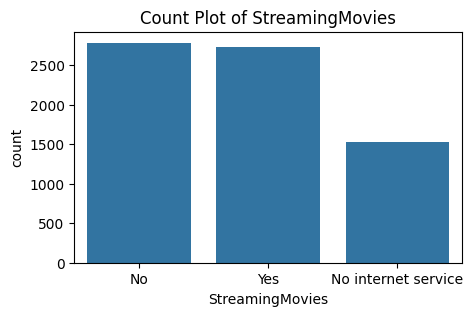

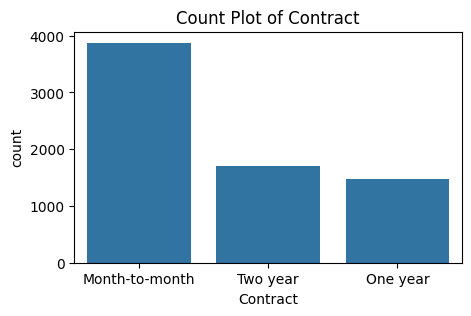

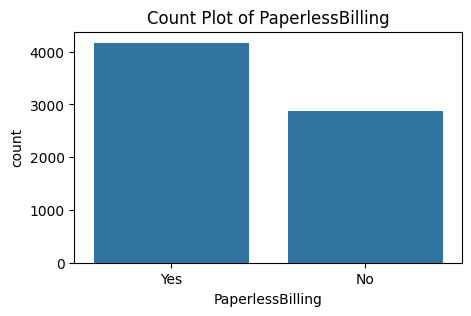

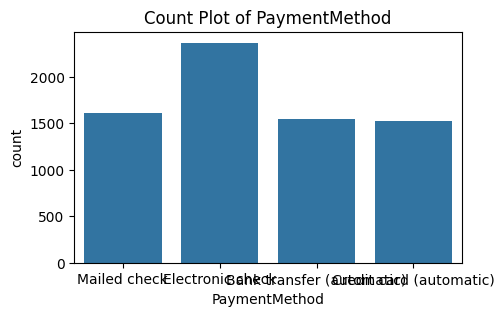

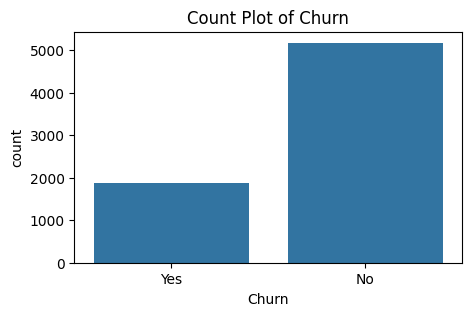

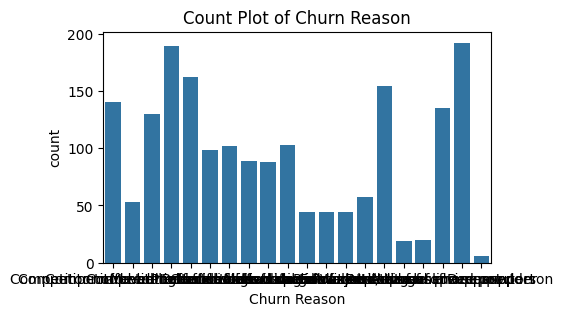

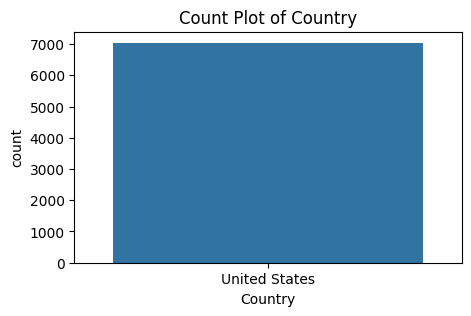

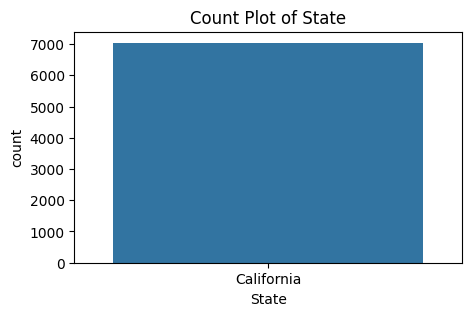

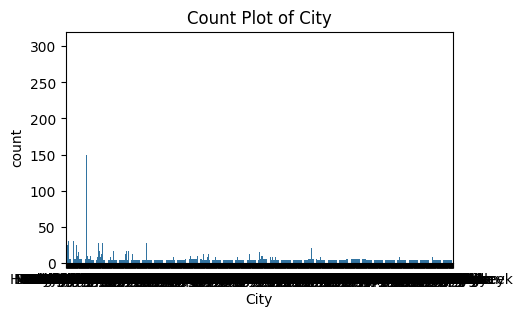

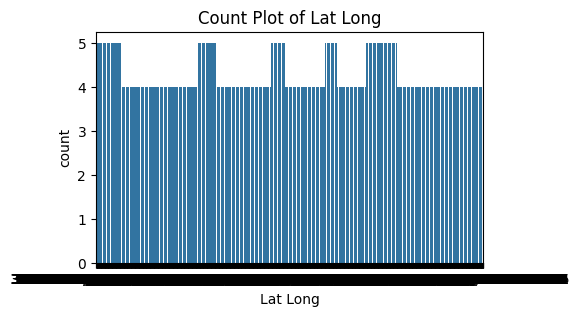

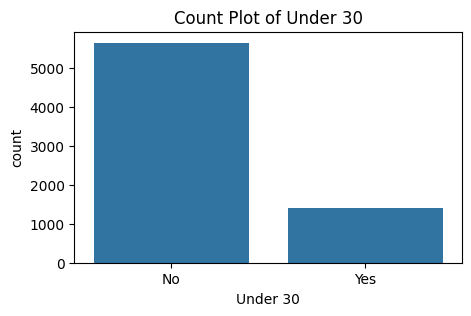

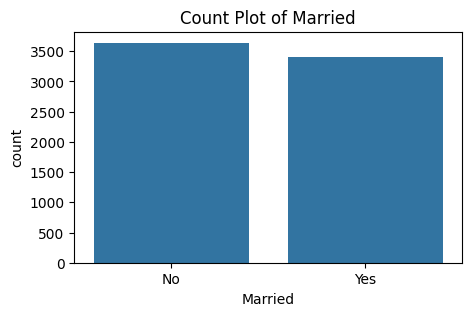

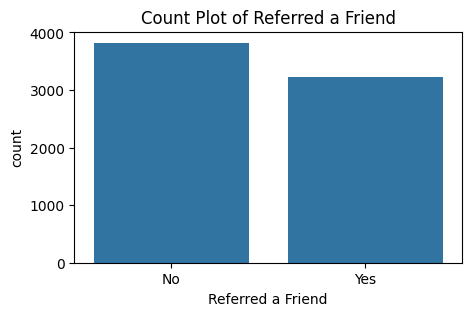

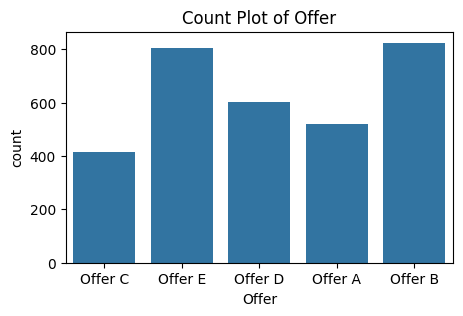

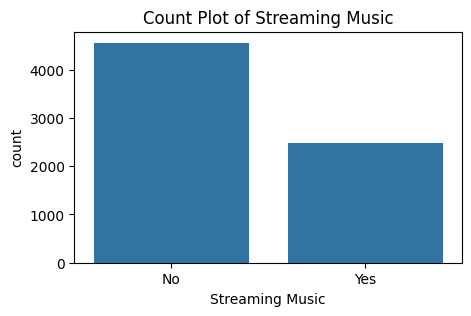

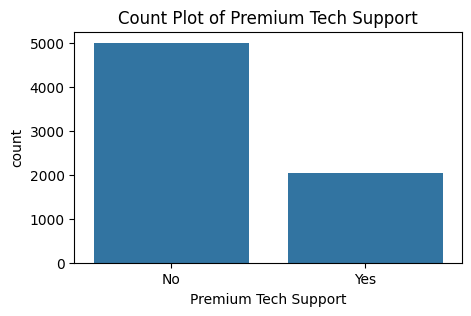

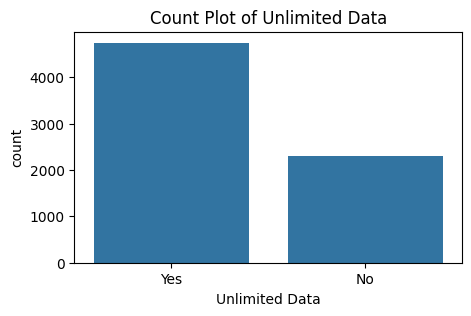

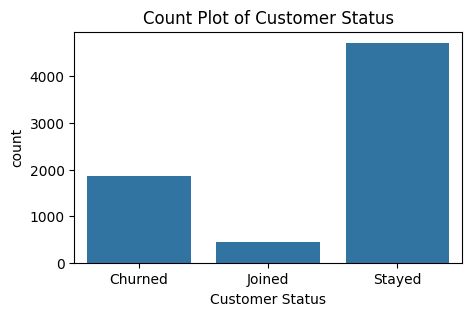

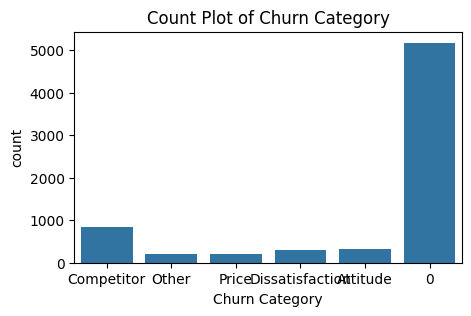

In [19]:
object_cols = df.select_dtypes(include="object").columns.to_list()

object_cols = ["SeniorCitizen"] + object_cols

for col in object_cols:
  plt.figure(figsize=(5, 3))
  sns.countplot(x=df[col])
  plt.title(f"Count Plot of {col}")
  plt.show()

4. Data Preprocessing

In [20]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_rate,CLTV,Churn Reason,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Age,Under 30,Married,Referred a Friend,Number of Referrals,Offer,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Streaming Music,Premium Tech Support,Unlimited Data,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Category
0,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,3239,Competitor made better offer,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,37,No,No,No,0,NaN,10.47,21,No,No,Yes,0.0,0,20.94,129.09,1,Churned,Competitor
1,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,2701,Moved,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,19,Yes,No,No,0,NaN,9.12,51,No,No,Yes,0.0,0,18.24,169.89,2,Churned,Other
2,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,5372,Moved,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,31,No,No,No,0,NaN,12.15,26,Yes,No,Yes,0.0,0,97.20,917.70,3,Churned,Other


Label encoding of target column

In [21]:
pd.set_option('future.no_silent_downcasting', True)
df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})

In [22]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


Label encoding of categorical fetaures

In [23]:
# identifying columns with object data type
object_columns = df.select_dtypes(include="object").columns
print(object_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn', 'Churn Reason', 'Country',
       'State', 'City', 'Lat Long', 'Under 30', 'Married', 'Referred a Friend',
       'Offer', 'Streaming Music', 'Premium Tech Support', 'Unlimited Data',
       'Customer Status', 'Churn Category'],
      dtype='object')


In [24]:
# initialize a dictionary to save the encoders
encoders = {}

# apply label encoding and store the encoders
for column in object_columns:
  label_encoder = LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder


# save the encoders to a pickle file
with open("encoders.pkl", "wb") as f:
  pickle.dump(encoders, f)

In [25]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_rate,CLTV,Churn Reason,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Age,Under 30,Married,Referred a Friend,Number of Referrals,Offer,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Streaming Music,Premium Tech Support,Unlimited Data,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Category
0,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1,1,3239,3,1,0,0,562,90003,327,33.964131,-118.272783,37,0,0,0,0,5,10.47,21,0,0,1,0.0,0,20.94,129.09,1,0,2
1,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1,1,2701,13,1,0,0,562,90005,405,34.059281,-118.307420,19,1,0,0,0,5,9.12,51,0,0,1,0.0,0,18.24,169.89,2,0,4
2,0,0,0,0,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50,1,1,5372,13,1,0,0,562,90006,393,34.048013,-118.293953,31,0,0,0,0,5,12.15,26,1,0,1,0.0,0,97.20,917.70,3,0,4
3,0,0,1,0,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05,1,1,5003,13,1,0,0,562,90010,410,34.062125,-118.315709,23,1,1,0,0,2,4.89,47,1,1,1,0.0,0,136.92,3182.97,3,0,4
4,1,0,0,0,49,1,2,1,0,2,2,0,2,2,0,1,0,103.70,5036.30,1,1,5340,2,1,0,0,562,90015,385,34.039224,-118.266293,38,0,0,0,0,5,44.33,11,1,0,1,0.0,0,2172.17,7208.47,1,0,2


5. Train-Test-Split

In [26]:
# splitting the features and target
# List of columns that perfectly predict 'Churn' and cause data leakage
leaky_columns = [
    "Churn", 
    "churn_rate", 
    "Churn Reason", 
    "Customer Status", 
    "Churn Category"
]

# Splitting the features and target (dropping all leaky columns)
X = df.drop(columns=leaky_columns)
y = df["Churn"]

In [27]:
# split training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
print(y_train.shape)

(5634,)


In [29]:
print(y_train.value_counts())

Churn
0    4165
1    1469
Name: count, dtype: int64


Synthetic Minority Oversampling TEchnique (SMOTE)

data augmentation method used in machine learning to address class imbalance

In [30]:
smote = SMOTE(random_state=42)

In [31]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [32]:
print(y_train_smote.shape)

(8330,)


In [33]:
print(y_train_smote.value_counts())

Churn
0    4165
1    4165
Name: count, dtype: int64


6. Model Training

Training with default hyperparameters

In [34]:
# dictionary of models
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(random_state=42)),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [35]:
# dictionary to store the cross validation results
cv_scores = {}

# perform 5-fold cross validation for each model
for model_name, model in models.items():
  print(f"Training {model_name} with default parameters")
  scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
  cv_scores[model_name] = scores
  print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")
  print("-"*70)

Training Logistic Regression with default parameters
Logistic Regression cross-validation accuracy: 0.96
----------------------------------------------------------------------
Training Random Forest with default parameters
Random Forest cross-validation accuracy: 0.97
----------------------------------------------------------------------
Training XGBoost with default parameters
XGBoost cross-validation accuracy: 0.96
----------------------------------------------------------------------


/tmp/ipykernel_55/2328197477.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


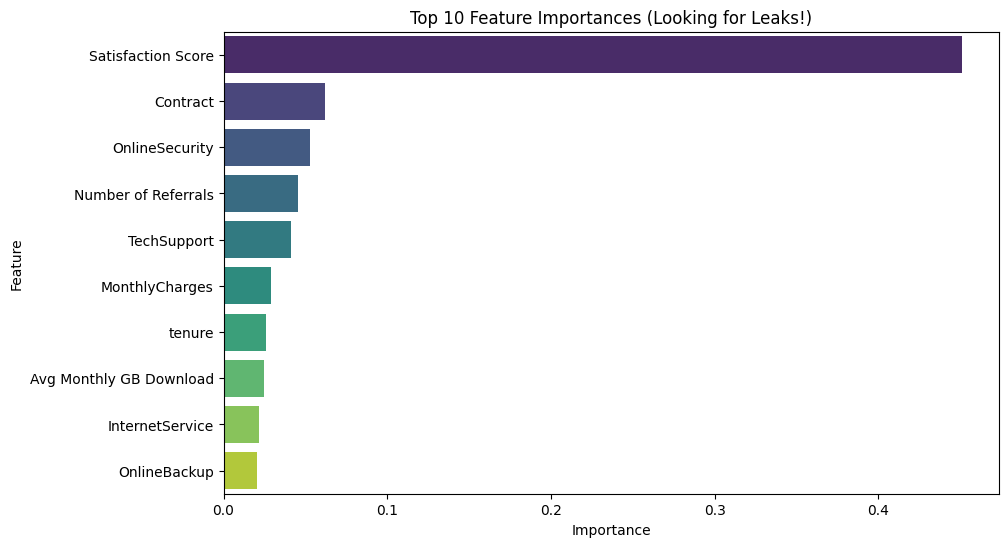

In [36]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_smote, y_train_smote)# Extract importances
importances = rf_model.feature_importances_
features = X.columns# Create a sorted DataFrame
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances (Looking for Leaks!)')
plt.show() 

Re-doing the entire thing to correct the leaky pipeline

In [37]:
#Adding Satisfaction Score for better training
leaky_columns = [
    "Churn", 
    "churn_rate", 
    "Churn Reason", 
    "Customer Status", 
    "Churn Category",
    "Satisfaction Score"
]

# Splitting the features and target (dropping all leaky columns)
X = df.drop(columns=leaky_columns)
y = df["Churn"]

In [38]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
print(y_train.shape)

(5634,)


In [40]:
print(y_train.value_counts())

Churn
0    4165
1    1469
Name: count, dtype: int64


In [41]:
smote = SMOTE(random_state=42)

In [42]:
print(y_train_smote.shape)

(8330,)


In [43]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [44]:
print(y_train_smote.value_counts())

Churn
0    4165
1    4165
Name: count, dtype: int64


6. Comparison of four model

In [45]:
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(random_state=42)),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "Neural Network": make_pipeline(
    StandardScaler(), 
    MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))

}

In [46]:
cv_scores = {}

for model_name, model in models.items():
  print(f"Training {model_name} with default parameters")
  scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
  cv_scores[model_name] = scores
  print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")
  print("-"*70)

Training Logistic Regression with default parameters
Logistic Regression cross-validation accuracy: 0.83
----------------------------------------------------------------------
Training Random Forest with default parameters
Random Forest cross-validation accuracy: 0.86
----------------------------------------------------------------------
Training XGBoost with default parameters
XGBoost cross-validation accuracy: 0.86
----------------------------------------------------------------------
Training Neural Network with default parameters
Neural Network cross-validation accuracy: 0.83
----------------------------------------------------------------------


In [47]:
cv_scores

{'Logistic Regression': array([0.72509004, 0.77430972, 0.88055222, 0.86794718, 0.88115246]),
 'Random Forest': array([0.76110444, 0.81212485, 0.92376951, 0.91056423, 0.91356543]),
 'XGBoost': array([0.74009604, 0.79771909, 0.92857143, 0.91776711, 0.92436975]),
 'Neural Network': array([0.69747899, 0.77070828, 0.90216086, 0.89735894, 0.88835534])}


 TRAINING & EVALUATING: Logistic Regression
Accuracy Score: 0.7729
F1 Score: 0.6444

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.79      0.83      1009
     Churned       0.58      0.72      0.64       400

    accuracy                           0.77      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.79      0.77      0.78      1409



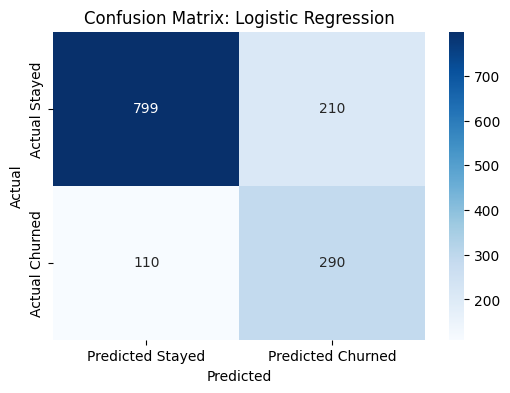


 TRAINING & EVALUATING: Random Forest
Accuracy Score: 0.7991
F1 Score: 0.6519

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.86      0.85      0.86      1009
     Churned       0.64      0.66      0.65       400

    accuracy                           0.80      1409
   macro avg       0.75      0.76      0.76      1409
weighted avg       0.80      0.80      0.80      1409



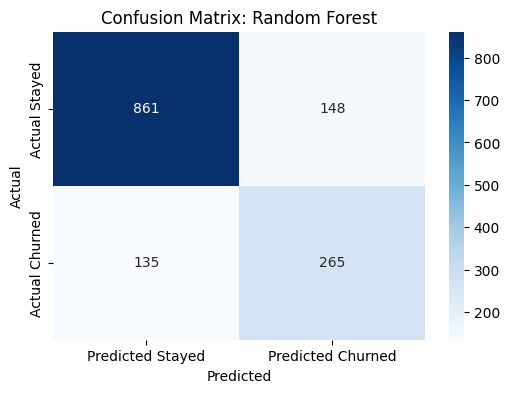


 TRAINING & EVALUATING: XGBoost
Accuracy Score: 0.7935
F1 Score: 0.6438

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.86      0.85      0.85      1009
     Churned       0.63      0.66      0.64       400

    accuracy                           0.79      1409
   macro avg       0.75      0.75      0.75      1409
weighted avg       0.80      0.79      0.79      1409



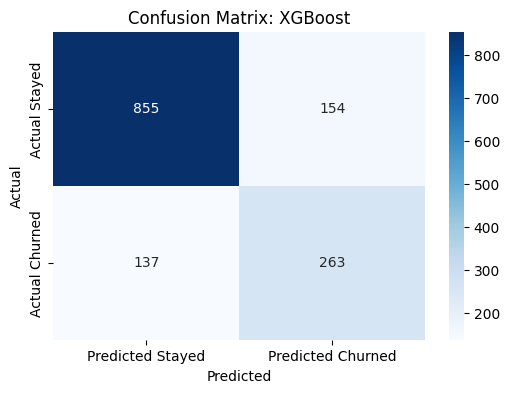


 TRAINING & EVALUATING: Neural Network
Accuracy Score: 0.7693
F1 Score: 0.6080

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.82      0.84      1009
     Churned       0.59      0.63      0.61       400

    accuracy                           0.77      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.77      0.77      0.77      1409



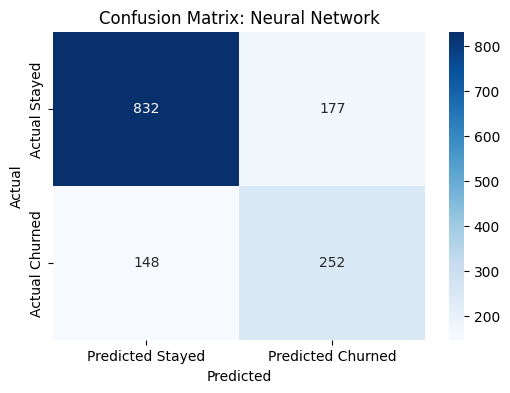

In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Iterate through each model in your dictionary
for name, model in models.items():
    print(f"\n{'='*40}")
    print(f" TRAINING & EVALUATING: {name}")
    print(f"{'='*40}")
    
    # --- THE FIX: Fit the model on the full training data first ---
    model.fit(X_train_smote, y_train_smote)
    
    # 1. Generate predictions
    y_pred = model.predict(X_test)
    
    # 2. Print high-level metrics
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    
    # 3. Print the detailed Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))
    
    # 4. Generate and Plot the Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Stayed', 'Predicted Churned'],
                yticklabels=['Actual Stayed', 'Actual Churned'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

7. SHAP

Generating SHAP summary for: Logistic Regression


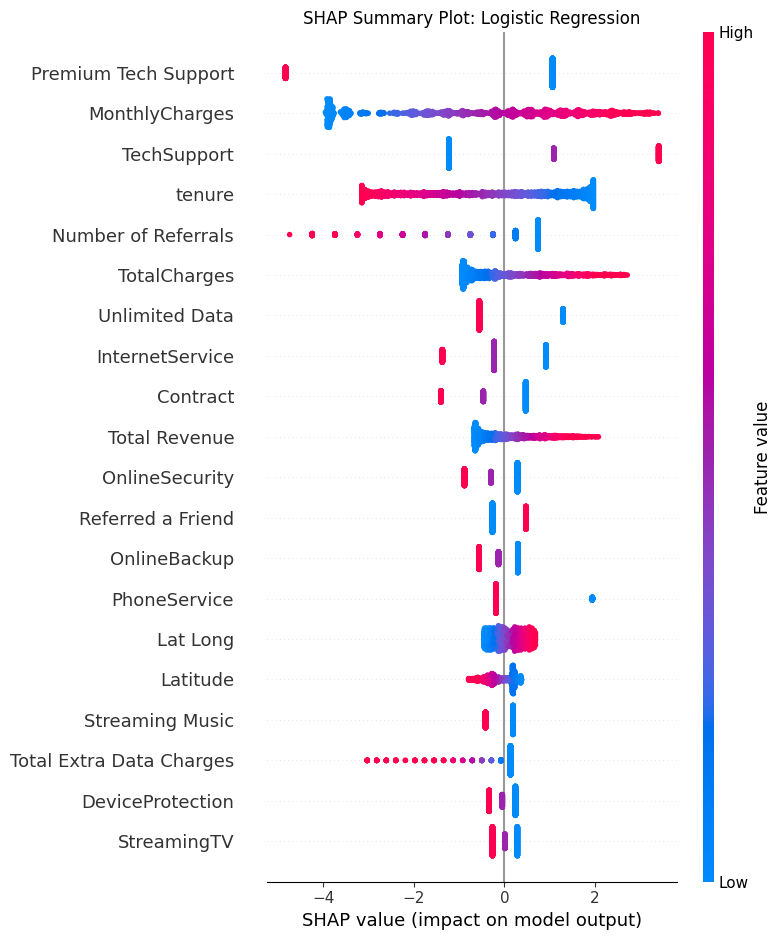

Generating SHAP summary for: Random Forest


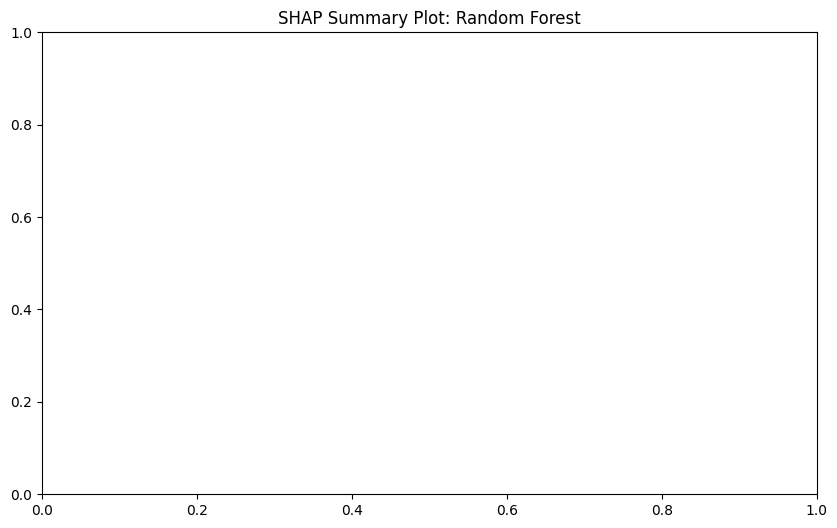

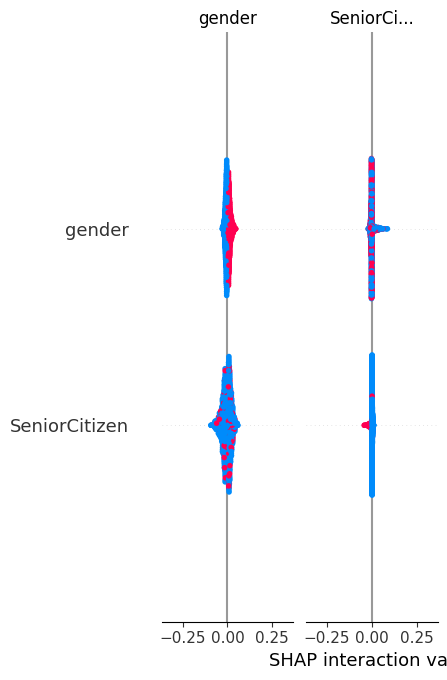

Generating SHAP summary for: XGBoost


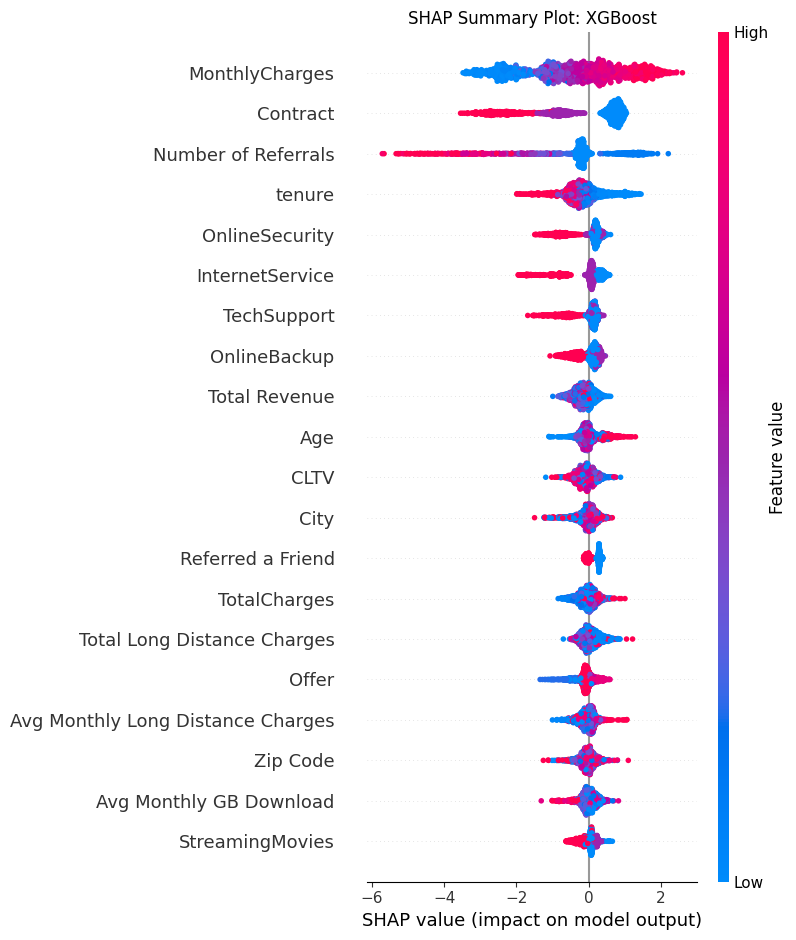

Generating SHAP summary for: Neural Network


  0%|          | 0/50 [00:00<?, ?it/s]

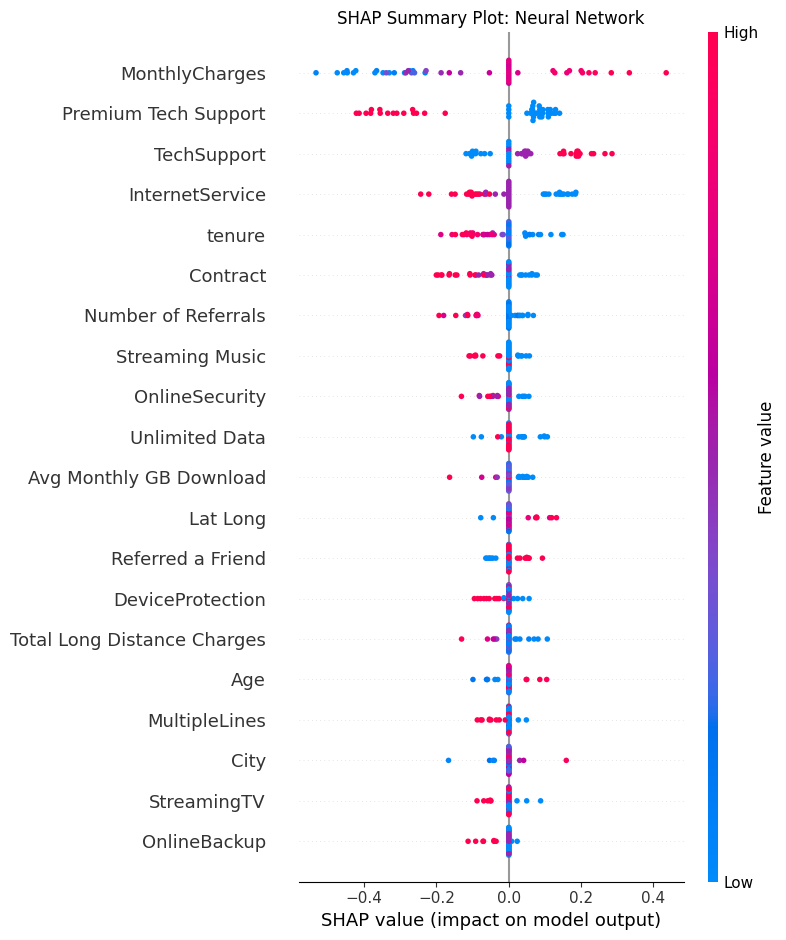

In [50]:
import shap
import matplotlib.pyplot as plt

# Ensure SHAP is initialized for JS (for interactive plots, though summary_plot is static)
shap.initjs()

for name, model in models.items():
    print(f"Generating SHAP summary for: {name}")
    
    # 1. Prepare the model and the specific data it needs
    if "pipeline" in str(type(model)).lower():
        # For Pipelines (Logistic Regression & Neural Network)
        # We extract the scaler and the classifier
        scaler = model.steps[0][1]
        classifier = model.steps[1][1]
        X_test_ready = scaler.transform(X_test)
        feature_names = X.columns
    else:
        # For Standalone models (Random Forest & XGBoost)
        classifier = model
        X_test_ready = X_test
        feature_names = X.columns

    # 2. Select the correct Explainer
    try:
        if name == "Logistic Regression":
            # Linear Explainer is fast and accurate for linear models
            explainer = shap.LinearExplainer(classifier, scaler.transform(X_train_smote))
            shap_values = explainer.shap_values(X_test_ready)
            
        elif name in ["Random Forest", "XGBoost"]:
            # Tree Explainer is optimized for tree-based models
            explainer = shap.TreeExplainer(classifier)
            shap_values = explainer.shap_values(X_test_ready)
            # Random Forest often returns a list [values_for_0, values_for_1]
            if isinstance(shap_values, list):
                shap_values = shap_values[1] # Focus on 'Churn' class
                
        elif name == "Neural Network":
            # Kernel Explainer is model-agnostic (works for MLP)
            # We use a small background sample to keep it fast
            background = shap.sample(scaler.transform(X_train_smote), 50)
            explainer = shap.KernelExplainer(classifier.predict, background)
            shap_values = explainer.shap_values(shap.sample(X_test_ready, 50))
            # Match the test sample for plotting
            X_test_ready = shap.sample(X_test_ready, 50)

        # 3. Plot the Summary
        plt.figure(figsize=(10, 6))
        plt.title(f"SHAP Summary Plot: {name}")
        shap.summary_plot(shap_values, X_test_ready, feature_names=feature_names, show=False)
        plt.show()
        
    except Exception as e:
        print(f"Could not generate SHAP for {name}: {e}")

In [51]:
#trying another way


Generating SHAP summary for: Logistic Regression...


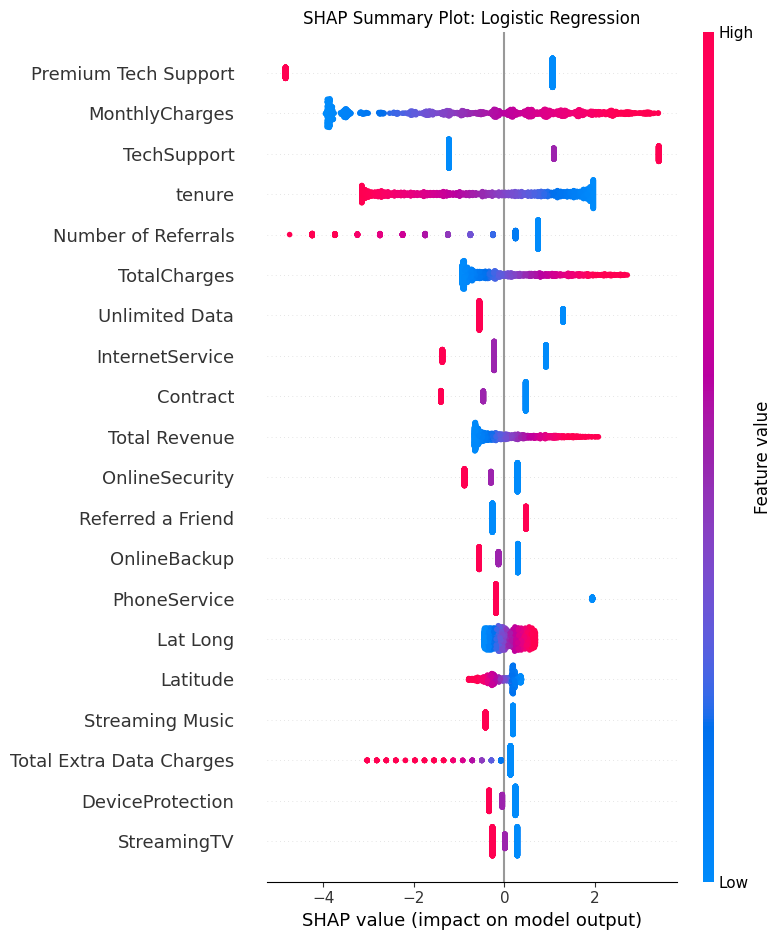


Generating SHAP summary for: Random Forest...


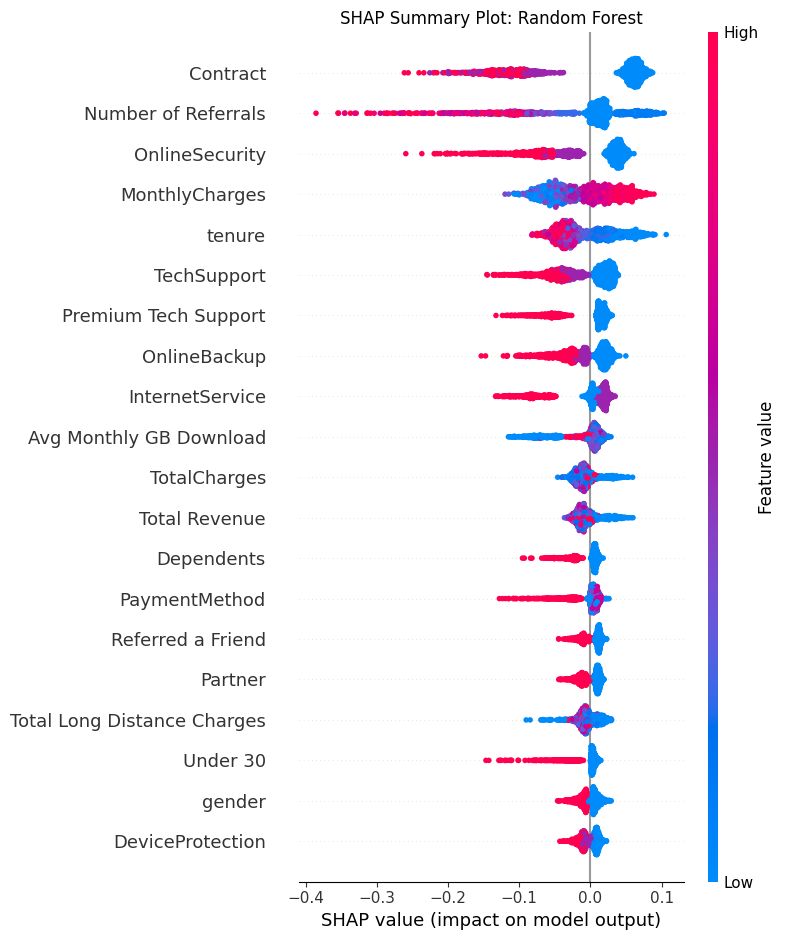


Generating SHAP summary for: XGBoost...


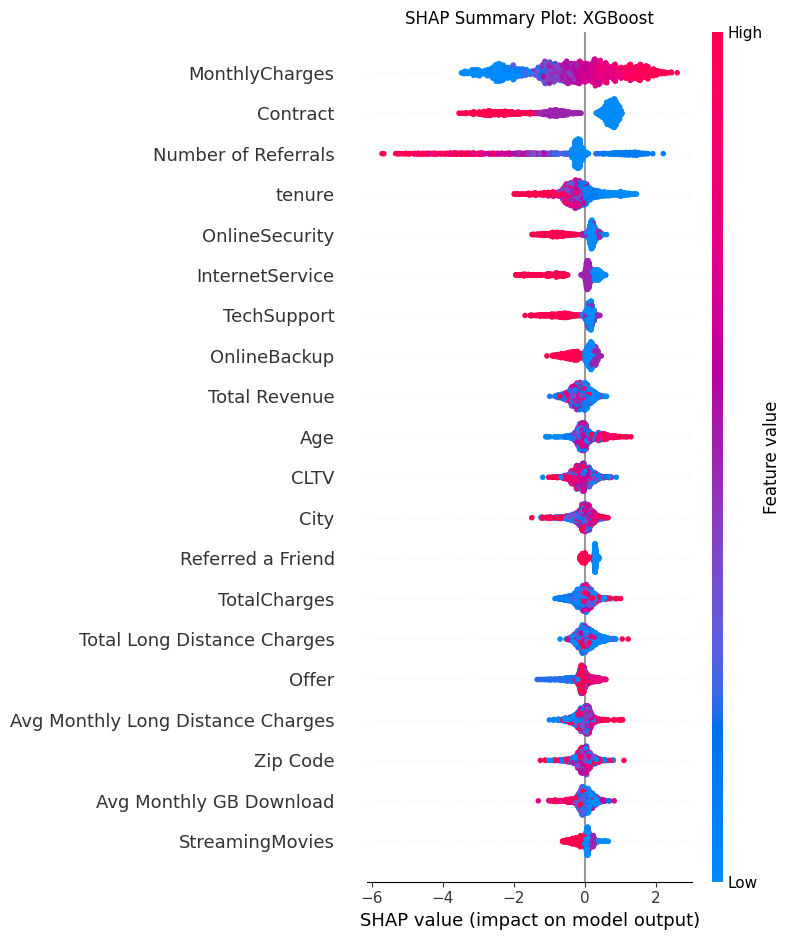


Generating SHAP summary for: Neural Network...


  0%|          | 0/50 [00:00<?, ?it/s]

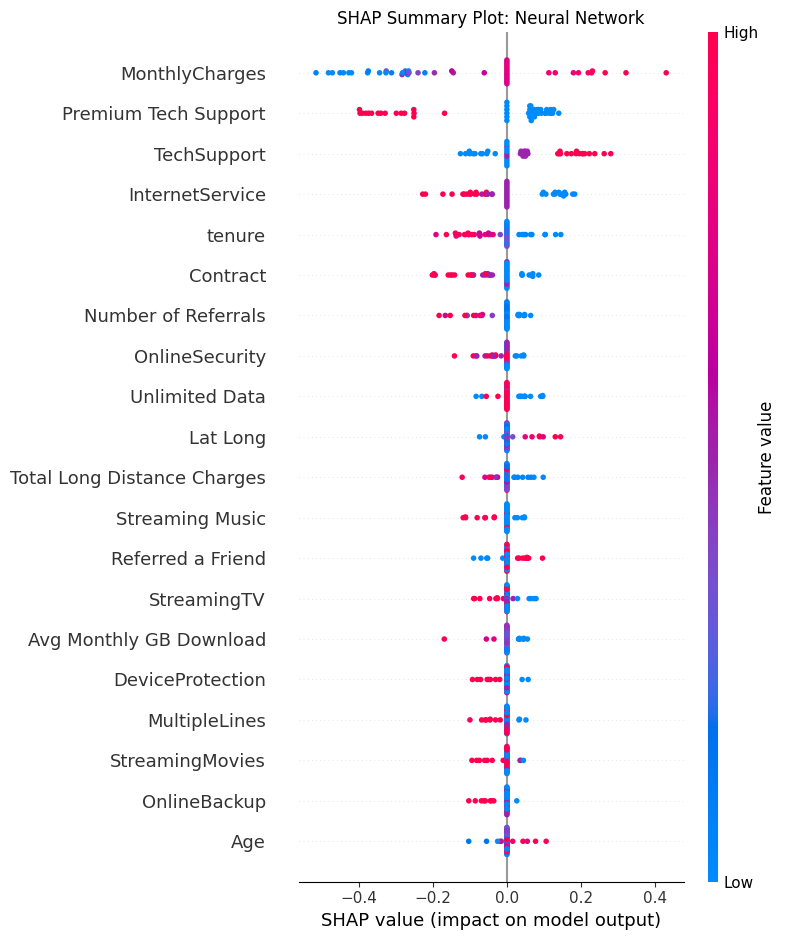

In [52]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Initialize SHAP
shap.initjs()

for name, model in models.items():
    print(f"\nGenerating SHAP summary for: {name}...")
    
    try:
        # 1. Prepare the model and the specific data it needs
        if "pipeline" in str(type(model)).lower():
            scaler = model.named_steps.get('standardscaler')
            classifier = model.steps[-1][1] 
            X_test_ready = scaler.transform(X_test)
        else:
            classifier = model
            X_test_ready = X_test

        # 2. Select and run the correct Explainer
        if name == "Logistic Regression":
            explainer = shap.LinearExplainer(classifier, scaler.transform(X_train_smote))
            shap_values = explainer.shap_values(X_test_ready)
            
        elif name == "Random Forest":
            explainer = shap.TreeExplainer(classifier)
            shap_values = explainer.shap_values(X_test_ready)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
            elif len(shap_values.shape) == 3:
                shap_values = shap_values[:, :, 1]
        
        elif name == "XGBoost":
            # --- SPECIFIC FIX FOR XGBOOST ---
            # TreeExplainer is best, but sometimes needs model_output='probability'
            explainer = shap.TreeExplainer(classifier)
            shap_values = explainer.shap_values(X_test_ready)
            
            # XGBoost often outputs a single set of values for binary classification.
            # If it outputs two (like RF), we slice for the positive class.
            if isinstance(shap_values, list) and len(shap_values) > 1:
                shap_values = shap_values[1]
                
        elif name == "Neural Network":
            background = shap.sample(scaler.transform(X_train_smote), 50)
            test_sample = shap.sample(X_test_ready, 50)
            explainer = shap.KernelExplainer(classifier.predict, background)
            shap_values = explainer.shap_values(test_sample)
            X_test_ready = test_sample 

        # 3. Plot the Summary
        plt.figure(figsize=(10, 6))
        # Ensure we pass a DataFrame to SHAP for better feature naming
        shap.summary_plot(shap_values, X_test_ready, feature_names=X.columns, show=False)
        plt.title(f"SHAP Summary Plot: {name}")
        plt.tight_layout() # Prevents label cutoff
        plt.show()
        
    except Exception as e:
        print(f"Error generating SHAP for {name}: {e}")